In [1]:
import tensorflow as tensorflow
from tensorflow import keras
import numpy as np 
import matplotlib.pyplot as plt
print(tensorflow.config.list_physical_devices('GPU'))

[]


In [2]:
#importing the dataset and testing it
(X_train , Y_train),(X_test,Y_test) = keras.datasets.mnist.load_data() 
np.set_printoptions(linewidth=200)
print("Train shape",X_train.shape,Y_train.shape)
print("Test shape",X_test.shape,Y_test.shape)
print(X_train[0])
print("now the output")
print(Y_train)

print(Y_train.shape)

Train shape (60000, 28, 28) (60000,)
Test shape (10000, 28, 28) (10000,)
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0  

In [3]:
#normalizing the dataset
np.set_printoptions(linewidth=200)
X_train = X_train / 255.0
X_test = X_test/ 255.0
print(X_train[0])

[[0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.         0.         0.    

In [4]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128,activation = "relu"),
    keras.layers.Dense(64,activation = "relu"),
    keras.layers.Dense(10,activation = "softmax"),
])
model.summary()

c:\Users\jhitheshwaran\OneDrive\Desktop\all files\ML\Handwriiten-Digit-Recognition\tf_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(loss = 'sparse_categorical_crossentropy',optimizer = 'adam',metrics = ['accuracy'])
print(X_train.shape, X_train.min(), X_train.max())
print(Y_train.shape, Y_train[:10])

(60000, 28, 28) 0.0 1.0
(60000,) [5 0 4 1 9 2 1 3 1 4]


In [6]:
history = model.fit(X_train,Y_train,epochs=10,validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9256 - loss: 0.2536 - val_accuracy: 0.9690 - val_loss: 0.1059
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9672 - loss: 0.1057 - val_accuracy: 0.9668 - val_loss: 0.1077
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9777 - loss: 0.0729 - val_accuracy: 0.9772 - val_loss: 0.0773
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9829 - loss: 0.0535 - val_accuracy: 0.9748 - val_loss: 0.0895
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9861 - loss: 0.0425 - val_accuracy: 0.9750 - val_loss: 0.0909
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9881 - loss: 0.0347 - val_accuracy: 0.9760 - val_loss: 0.0860
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9899 - loss: 0.0299 - val_accuracy: 0.9762 - val_loss: 0.1009
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9921 - loss: 0.0238 - 

In [7]:
test_loss , test_acc = model.evaluate(X_test,Y_test)
print("The test loss is ",test_loss)
print("The test accuracy is",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - accuracy: 0.9733 - loss: 0.1186
The test loss is  0.11857094615697861
The test accuracy is 0.9732999801635742


In [8]:
predictions = model.predict(X_test)
predicted_lables = np.argmax(predictions,axis = 1)
print(predicted_lables)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 692us/step
[7 2 1 ... 4 5 6]


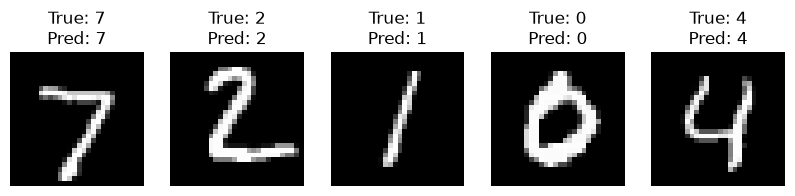

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_test[i],cmap='gray')
    ax.set_title(f"True: {Y_test[i]}\nPred: {predicted_lables[i]}")
    ax.axis('off')
plt.show()

Number of misclassified digits: 267


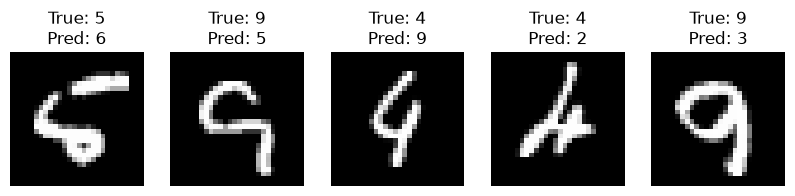

In [10]:
wrong_indices = np.where(predicted_lables != Y_test)[0]
print(f"Number of misclassified digits: {len(wrong_indices)}")

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes[:5]):
    idx = wrong_indices[i]
    ax.imshow(X_test[idx], cmap='gray')
    ax.set_title(f"True: {Y_test[idx]}\nPred: {predicted_lables[idx]}")
    ax.axis('off')
plt.show()

In [11]:
model.save('digit_recognizer.keras')